<a href="https://colab.research.google.com/github/AamnahFaiyaz/CodSoft/blob/main/Sales_Prediction/Aamnah_Faiyaz_Sales_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Introduction

This notebook demonstrates a simple sales prediction project using a Linear Regression model. The goal is to predict product sales based on advertising budgets spent on TV, Radio, and Newspaper. We will use `pandas` for data manipulation, `matplotlib` and `seaborn` for visualization, and `scikit-learn` for machine learning tasks.

## 2. Setup: Import Libraries

First, we'll import all the necessary Python libraries.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

## 3. Data Loading and Initial Exploration

We will load the dataset directly from a GitHub raw link into a pandas DataFrame and then perform some initial checks like viewing the first few rows and checking data types and non-null values.

In [2]:
# Define the dataset URL
dataset_url = 'https://raw.githubusercontent.com/AamnahFaiyaz/CodSoft/main/Sales_Prediction/advertising.csv'

# Load the dataset into a pandas DataFrame
df = pd.read_csv(dataset_url)

# Display the first 5 rows of the dataset
print("First 5 rows of the dataset:")
display(df.head())

# Display general information about the dataset
print("\nDataset Information:")
df.info()

First 5 rows of the dataset:


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


## 4. Data Cleaning: Check for Missing Values

It's important to check if there are any missing values in our dataset, as they can affect model training.

In [3]:
# Check for missing values in each column
print("\nMissing values in each column:")
display(df.isnull().sum())

# Since there are no missing values, we don't need to handle them.


Missing values in each column:


,0
TV,0
Radio,0
Newspaper,0
Sales,0


## 5. Exploratory Data Analysis: Correlation Heatmap

A correlation heatmap helps us understand the relationships between different variables in the dataset. A higher correlation (closer to 1 or -1) indicates a stronger relationship.

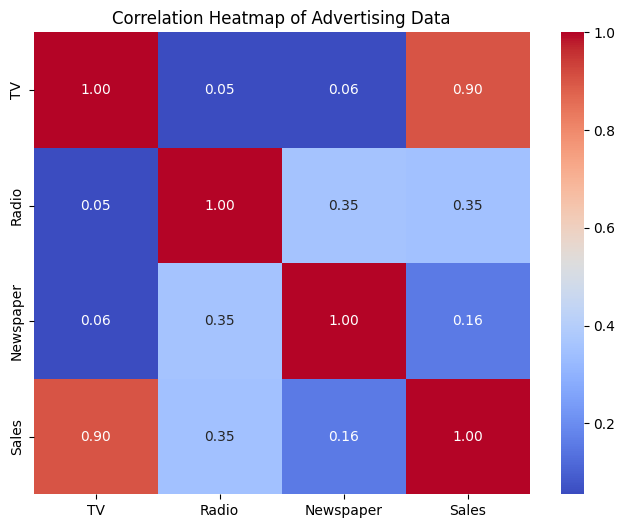

In [4]:
# Calculate the correlation matrix
correlation_matrix = df.corr()

# Plot the correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Advertising Data')
plt.show()

## 6. Data Preparation: Features and Target Variable

We define our input features (independent variables) as TV, Radio, and Newspaper advertising budgets, and our target variable (dependent variable) as Sales.

In [5]:
# Define input features (X) and target variable (y)
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

print("Input Features (X) head:")
display(X.head())
print("\nTarget Variable (y) head:")
display(y.head())

Input Features (X) head:


,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4



Target Variable (y) head:


,Sales
0,22.1
1,10.4
2,12.0
3,16.5
4,17.9


## 7. Data Splitting: Training and Testing Sets

To evaluate our model's performance on unseen data, we split the dataset into training and testing sets. The training set is used to train the model, and the testing set is used to make predictions and evaluate the model.

In [6]:
# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")

Training set size: 160 samples
Testing set size: 40 samples


## 8. Model Training: Linear Regression

We will use a simple Linear Regression model, which is a fundamental algorithm for understanding the relationship between a dependent variable and one or more independent variables.

In [7]:
# Initialize the Linear Regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")
print(f"Model Coefficients: {model.coef_}")
print(f"Model Intercept: {model.intercept_}")

Linear Regression model trained successfully.
Model Coefficients: [0.05450927 0.10094536 0.00433665]
Model Intercept: 4.714126402214127


## 9. Model Prediction and Evaluation

After training, we use the model to predict sales on the test set and evaluate its performance using key metrics: R² Score, Mean Absolute Error (MAE), and Root Mean Squared Error (RMSE).

In [8]:
# Predict sales on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score: {r2:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

R² Score: 0.91
Mean Absolute Error (MAE): 1.27
Root Mean Squared Error (RMSE): 1.71


## 10. Visualization: Actual vs. Predicted Sales

A scatter plot visually compares the actual sales values against the sales values predicted by our model. Ideally, the points should lie close to a 45-degree line.

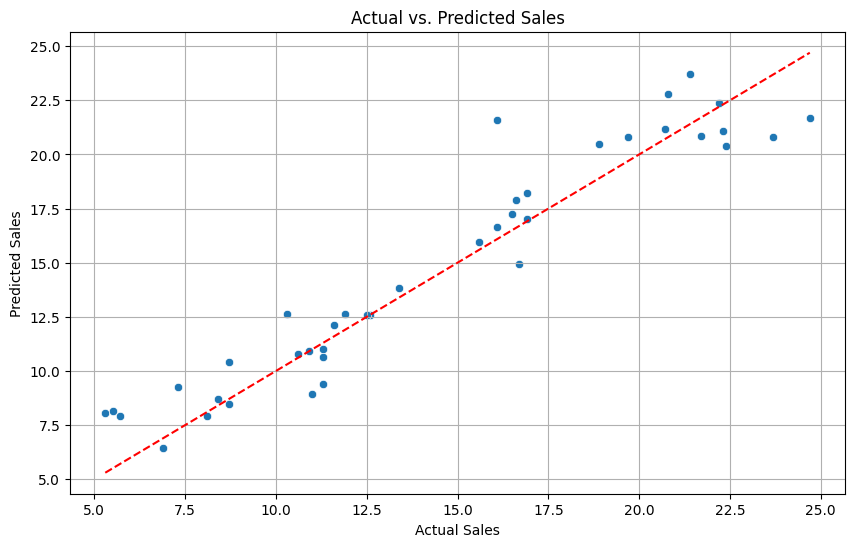

In [9]:
# Create a scatter plot of actual vs. predicted sales
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--') # Ideal line
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs. Predicted Sales')
plt.grid(True)
plt.show()

## 11. Conclusion

The Linear Regression model was trained to predict sales based on advertising budgets for TV, Radio, and Newspaper. The model achieved an R² score of **0.91**, indicating that approximately 91% of the variance in sales can be explained by our input features. The Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) further quantify the average magnitude of errors in our predictions. Overall, the model provides a reasonably good fit for predicting sales, which is a good starting point for a beginner project.